# Hamilton-Jacobi Reachability with Spatially-Varying Disturbance Landscapes
This notebook implements backward reachability analysis for a double integrator system subjected to a state-dependent adversarial disturbance bound field $d \in [-D(x), D(x)]$. 

We evaluate and compare two formulations:
1. **Full Game-Theoretic Formulation:** The controller fights a worst-case spatial adversary.
2. **Net Capability Formulation (Underapproximation):** The disturbance channel is zeroed out, but the control authority is conservatively scaled down point-by-point to $U_{net}(x) = U_{max} - D(x)$.

We benchmark these formulations across 3 distinct environmental disturbance profiles.

In [2]:
# Imports

import jax
import jax.numpy as jnp
import numpy as np
import time
from tqdm.notebook import tqdm

from IPython.display import HTML
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objects as go

import hj_reachability as hj

from hj_reachability.systems.doubleint import DoubleIntegrator

/home/radams4r/HSL/.venv/lib/python3.12/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


In [3]:
# Implement Custom Dynamics Subclasses strictly adhering to dynamics.py signatures

class DoubleIntDynamics(hj.Dynamics):
    """True game-theoretic system where control minimizes and disturbance maximizes."""
    def __init__(self, u_max, landscape_fn):
        self.u_max = u_max
        self.landscape_fn = landscape_fn
        # Initialize base abstract class with tracking modes
        super().__init__(
            control_mode="min", 
            disturbance_mode="max", 
            control_space=None, 
            disturbance_space=None
        )

    def __call__(self, state, control, disturbance, time):
        x2 = state[1]
        # Extract inputs handling potential array-wrapping from the level-set solver
        u = control[0] if hasattr(control, "__len__") else control
        d = disturbance[0] if hasattr(disturbance, "__len__") else disturbance
        return jnp.array([x2, u + d])

    def optimal_control_and_disturbance(self, state, time, grad_value):
        D_x = self.landscape_fn(state)
        
        # control_mode="min" minimizes the Hamiltonian -> opposite sign of velocity gradient
        u_opt = -jnp.sign(grad_value[1]) * self.u_max
        
        # disturbance_mode="max" maximizes the Hamiltonian -> tracks sign of velocity gradient
        d_opt = jnp.sign(grad_value[1]) * D_x
        
        return jnp.array([u_opt]), jnp.array([d_opt])

    def partial_max_magnitudes(self, state, time, value, grad_value_box):
        D_x = self.landscape_fn(state)
        # Dimension 0 (Position): dx1/dt = x2 -> max speed is |x2|
        # Dimension 1 (Velocity): dx2/dt = u + d -> worst-case combined speed is U_max + D(x)
        return jnp.array([jnp.abs(state[1]), self.u_max + D_x])


class NetCapabilityDynamics(hj.Dynamics):
    """Conservative underapproximation system: zero disturbance, shrunk control authority."""
    def __init__(self, u_max, landscape_fn):
        self.u_max = u_max
        self.landscape_fn = landscape_fn
        super().__init__(
            control_mode="min", 
            disturbance_mode="max", 
            control_space=None, 
            disturbance_space=None
        )

    def __call__(self, state, control, disturbance, time):
        x2 = state[1]
        u = control[0] if hasattr(control, "__len__") else control
        return jnp.array([x2, u])

    def optimal_control_and_disturbance(self, state, time, grad_value):
        D_x = self.landscape_fn(state)
        u_net = jnp.maximum(0.0, self.u_max - D_x)  # Clamp lower bound to physical zero
        
        u_opt = -jnp.sign(grad_value[1]) * u_net
        return jnp.array([u_opt]), jnp.array([0.0])

    def partial_max_magnitudes(self, state, time, value, grad_value_box):
        D_x = self.landscape_fn(state)
        u_net = jnp.maximum(0.0, self.u_max - D_x)
        # u_net = self.u_max - D_x  # Allow negative values to reflect potential backward motion
        return jnp.array([jnp.abs(state[1]), u_net])

In [4]:
# Disturbance Landscapes

def landscape_1_uniform(state, d_max=1):
    """1. Uniform baseline disturbance everywhere."""
    return d_max

def landscape_2_patterned(state, d_base=0.8, A=0.25, wavelength=4.0):
    """2. Cyclical patterned disturbance using a sinusoidal wave."""
    x1 = state[0]
    return d_base + A * jnp.cos(2 * jnp.pi * x1 / wavelength)

def landscape_3_spike(state, d_base=0.1, A=0.55, center=0.0, sigma=0.35):
    """3. Highly localized wind corridor modeled via a Gaussian spike."""
    x1 = state[0]
    return d_base + A * jnp.exp(-((x1 - center) ** 2) / (2 * sigma ** 2))

def landscape_4_radial_growth(state, d_base=0.5, L=0.25):
    """4. Disturbance magnitude increasing linearly from the origin with Lipschitz constant L."""
    # Euclidean distance from origin: r = ||x||_2 = sqrt(x1^2 + x2^2)
    r = jnp.linalg.norm(state)
    return d_base + L * r

In [ ]:
# Parameters for the random Lipschitz disturbance landscape

L_D_target = 0.20   # Desired Lipschitz constant
L_T_target = 0.40   # Temporal Lipschitz bound
d_base = 0.1        # Minimum disturbance magnitude
seed = 102          # Random seed

epsilon_buffer = 0.02      # Re-sample when D_combined >= u_max - 0.02
min_step_dist = 0.3        # Minimum spatial step between samples
u_max = 1.0
extension = 5.0  # Extend the evaluation domain for the random landscape

# test set for sampled points
sampled_points = jnp.array([
    [-5.0,  3.0],
    [-5.5, 3.5],
    [-3.0, -4.0],
    # [ 1.0, -5.0]
])


In [6]:
# Grid Generation and Target Set Initialization

grid_lower = jnp.array([-10.0, -10.0])
grid_upper = jnp.array([10.0, 10.0])
grid_shape = (201, 201)

# Expand the grid bounds so the solver can trace the full trajectory expansion
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    domain=hj.sets.Box(
        grid_lower,     # Lower bounds: [min_position, min_velocity]
        grid_upper      # Upper bounds: [max_position, max_velocity]
    ),
    shape=grid_shape             # Grid resolution
)

# grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
#     hj.sets.Box(grid_lower, grid_upper), grid_shape
# )

# Safe target boundary defined as a terminal circle centered at the origin
safety_bound = 5.0
initial_values = jnp.linalg.norm(grid.states, axis=-1) - safety_bound

print(f"Grid successfully instantiated with shape {grid_shape}.")

Grid successfully instantiated with shape (201, 201).


In [7]:
# Random Lipschitz-Continuous Ground Truth Disturbance Generator

def create_random_spatio_lipschitz_landscape(
    grid, 
    L_D=0.25, 
    d_base=0.1, 
    sigma=2.5, 
    seed=101,
    extension=5.0,
    num_centers=None,      # Changed: Default to None so center_density takes effect automatically
    center_density=0.1    # Gaussian center density (centers per unit area)
):
    """Random Lipschitz-Continuous Ground Truth Disturbance Generator."""
    key = jax.random.PRNGKey(seed)
    key_c, key_w = jax.random.split(key)

    # Convert extension to a 2D vector if given as scalar
    ext = jnp.atleast_1d(jnp.array(extension, dtype=jnp.float32))
    if ext.shape == (1,):
        ext = jnp.repeat(ext, 2)

    # Extended domain bounds (e.g., [-15, -15] to [15, 15])
    eval_low = grid.domain.lo - ext
    eval_high = grid.domain.hi + ext
    
    domain_width = float(eval_high[0] - eval_low[0])
    domain_height = float(eval_high[1] - eval_low[1])
    area = domain_width * domain_height

    if num_centers is None:
        num_centers = max(12, int(round(area * center_density)))
    
    # Pad center sampling box by 2*sigma
    pad = 2.0 * sigma
    center_low = eval_low - pad
    center_high = eval_high + pad

    # Sample random center locations c_k within padded extended bounds
    centers = jax.random.uniform(
        key_c, shape=(num_centers, 2), 
        minval=center_low, maxval=center_high
    )
    weights = jax.random.uniform(
        key_w, shape=(num_centers,), 
        minval=-1.0, maxval=1.0
    )
    
    # Unscaled RBF function sum for a single state (2,)
    def unscaled_f(state):
        diffs = state - centers  # Shape: (num_centers, 2)
        dist_sq = jnp.sum(diffs**2, axis=-1)
        return jnp.sum(weights * jnp.exp(-dist_sq / (2.0 * sigma**2)))

    # Create temporary extended grid to evaluate max gradient & baseline shift across the full domain
    scale_shape = (
        int(grid.shape[0] * (eval_high[0] - eval_low[0]) / (grid.domain.hi[0] - grid.domain.lo[0])),
        int(grid.shape[1] * (eval_high[1] - eval_low[1]) / (grid.domain.hi[1] - grid.domain.lo[1]))
    )
    ext_grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
        domain=hj.sets.Box(eval_low, eval_high),
        shape=scale_shape
    )

    # Measure spatial gradient ||grad f(x)||_2 across extended grid using vmap
    grad_fn = jax.grad(unscaled_f)
    ext_states = ext_grid.states  
    
    unscaled_map = jax.vmap(jax.vmap(unscaled_f))(ext_states)
    spatial_grads = jax.vmap(jax.vmap(grad_fn))(ext_states)
    grad_norms = jnp.linalg.norm(spatial_grads, axis=-1)
    
    max_measured_grad = jnp.max(grad_norms)
    min_unscaled_val = jnp.min(unscaled_map)

    # Scale factor so peak spatial gradient equals L_D exactly
    scale_factor = L_D / max_measured_grad

    # Final Ground Truth Disturbance Function D_true(state)
    def d_true_fn(state):
        raw_val = scale_factor * unscaled_f(state)
        # Shift baseline so minimum value across extended grid is d_base
        return raw_val - scale_factor * min_unscaled_val + d_base

    return d_true_fn

In [8]:
### time varying disturbance landscape generator

# Step 1: Spatio-Temporally Varying Disturbance Landscape & Animation Generator

# %%
def create_spatiotemporal_lipschitz_landscape(
    grid, 
    L_D=0.20,           # Target Spatial Lipschitz bound
    L_T=0.10,           # Target Temporal Lipschitz bound (units/sec)
    d_base=0.10,         # Minimum baseline disturbance
    start_uniform=True, # Option to start with flat uniform field at t=0
    seed=101,
    extension=5.0,
    center_density=0.1,
    num_frequencies=3,
    t_max=10.0
):
    """
    Generates a JAX-differentiable spatio-temporally varying disturbance landscape D_true(state, time).
    Strictly guarantees that both spatial (L_D) and temporal (L_T) Lipschitz bounds are preserved.
    """
    key = jax.random.PRNGKey(seed)
    key_c, key_w, key_freq, key_phase = jax.random.split(key, 4)

    ext = jnp.atleast_1d(jnp.array(extension, dtype=jnp.float32))
    if ext.shape == (1,):
        ext = jnp.repeat(ext, 2)

    eval_low = grid.domain.lo - ext
    eval_high = grid.domain.hi + ext
    
    domain_width = float(eval_high[0] - eval_low[0])
    domain_height = float(eval_high[1] - eval_low[1])
    area = domain_width * domain_height

    num_centers = max(12, int(round(area * center_density)))
    sigma = 2.5
    pad = 2.0 * sigma

    center_low = eval_low - pad
    center_high = eval_high + pad

    centers = jax.random.uniform(key_c, shape=(num_centers, 2), minval=center_low, maxval=center_high)
    amplitudes = jax.random.uniform(key_w, shape=(num_centers, num_frequencies), minval=-1.0, maxval=1.0)
    omegas = jax.random.uniform(key_freq, shape=(num_centers, num_frequencies), minval=0.2, maxval=1.5)
    phases = jax.random.uniform(key_phase, shape=(num_centers, num_frequencies), minval=0.0, maxval=2 * jnp.pi)

    def weights_t(t):
        sin_terms = jnp.sin(omegas * t + phases)
        return jnp.sum(amplitudes * sin_terms, axis=-1)

    def unscaled_f(state, t):
        diffs = state - centers
        dist_sq = jnp.sum(diffs**2, axis=-1)
        rbf_vals = jnp.exp(-dist_sq / (2.0 * sigma**2))
        w = weights_t(t)
        return jnp.sum(w * rbf_vals)

    # Coarse evaluation grid for bound estimation
    scale_shape = (
        int(grid.shape[0] * (eval_high[0] - eval_low[0]) / (grid.domain.hi[0] - grid.domain.lo[0])),
        int(grid.shape[1] * (eval_high[1] - eval_low[1]) / (grid.domain.hi[1] - grid.domain.lo[1]))
    )
    ext_grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
        domain=hj.sets.Box(eval_low, eval_high),
        shape=scale_shape
    )

    spatial_grad_unscaled = jax.grad(unscaled_f, argnums=0)
    temporal_grad_unscaled = jax.grad(unscaled_f, argnums=1)

    sample_times = jnp.linspace(0.0, t_max, 25)

    def eval_unscaled_grads(t):
        states = ext_grid.states
        s_grads = jax.vmap(jax.vmap(lambda x: spatial_grad_unscaled(x, t)))(states)
        t_grads = jax.vmap(jax.vmap(lambda x: temporal_grad_unscaled(x, t)))(states)
        vals = jax.vmap(jax.vmap(lambda x: unscaled_f(x, t)))(states)
        return jnp.max(jnp.linalg.norm(s_grads, axis=-1)), jnp.max(jnp.abs(t_grads)), jnp.min(vals)

    s_grads_t, t_grads_t, min_vals_t = jax.vmap(eval_unscaled_grads)(sample_times)

    max_meas_s_grad = jnp.max(s_grads_t)
    max_meas_t_grad = jnp.max(t_grads_t)
    global_min_unscaled = jnp.min(min_vals_t)

    # Initial scaling parameters
    scale_spatial = L_D / max_meas_s_grad
    scaled_t_grad = scale_spatial * max_meas_t_grad
    time_rate_factor = jnp.minimum(1.0, L_T / scaled_t_grad)

    tau = 3.0  # Smooth transition scale for start_uniform option

    # Define provisional function
    def provisional_d_fn(state, t):
        eff_t = t * time_rate_factor
        raw_val = unscaled_f(state, eff_t)
        shifted_val = scale_spatial * (raw_val - global_min_unscaled)
        
        if start_uniform:
            alpha = jnp.tanh(t / tau)
            return d_base + alpha * shifted_val
        else:
            return d_base + shifted_val

    # Second pass: Check if start_uniform ramp introduced extra temporal derivative
    temporal_grad_prov = jax.grad(provisional_d_fn, argnums=1)
    
    def eval_prov_t_grad(t):
        states = ext_grid.states
        t_grads = jax.vmap(jax.vmap(lambda x: temporal_grad_prov(x, t)))(states)
        return jnp.max(jnp.abs(t_grads))

    prov_t_grads = jax.vmap(eval_prov_t_grad)(sample_times)
    max_prov_t_grad = jnp.max(prov_t_grads)

    # Safety factor to ensure strict compliance <= L_T
    final_safety_scale = jnp.minimum(1.0, L_T / (max_prov_t_grad + 1e-6))

    def d_true_fn(state, t):
        eff_t = t * time_rate_factor * final_safety_scale
        raw_val = unscaled_f(state, eff_t)
        shifted_val = scale_spatial * final_safety_scale * (raw_val - global_min_unscaled)
        
        if start_uniform:
            alpha = jnp.tanh(t / tau)
            return d_base + alpha * shifted_val
        else:
            return d_base + shifted_val

    return d_true_fn

# %%
def verify_spatiotemporal_bounds(d_true_fn, grid, t_span, L_D, L_T):
    """
    Numerically verifies spatial gradient norms and temporal derivatives 
    across the spatial grid over time.
    """
    spatial_grad_fn = jax.grad(d_true_fn, argnums=0)
    temporal_grad_fn = jax.grad(d_true_fn, argnums=1)

    states = grid.states
    eval_spatial = jax.vmap(jax.vmap(spatial_grad_fn, in_axes=(0, None)), in_axes=(0, None))
    eval_temporal = jax.vmap(jax.vmap(temporal_grad_fn, in_axes=(0, None)), in_axes=(0, None))
    eval_val = jax.vmap(jax.vmap(d_true_fn, in_axes=(0, None)), in_axes=(0, None))

    max_spatial_grads = []
    max_temporal_grads = []
    min_vals = []
    max_vals = []

    for t in t_span:
        s_grads = eval_spatial(states, t)
        t_grads = eval_temporal(states, t)
        vals = eval_val(states, t)

        s_norm = jnp.linalg.norm(s_grads, axis=-1)
        t_abs = jnp.abs(t_grads)

        max_spatial_grads.append(float(jnp.max(s_norm)))
        max_temporal_grads.append(float(jnp.max(t_abs)))
        min_vals.append(float(jnp.min(vals)))
        max_vals.append(float(jnp.max(vals)))

    max_s = max(max_spatial_grads)
    max_t = max(max_temporal_grads)

    print("==================================================")
    print("SPATIO-TEMPORAL LIPSCHITZ BOUND VERIFICATION")
    print("==================================================")
    print(f"Target Spatial Lipschitz Bound (L_D)  : {L_D:.4f}")
    print(f"Max Measured Spatial Gradient        : {max_s:.4f}  (Pass: {max_s <= L_D + 1e-3})")
    print(f"Target Temporal Lipschitz Bound (L_T) : {L_T:.4f}")
    print(f"Max Measured Temporal Rate           : {max_t:.4f}  (Pass: {max_t <= L_T + 1e-3})")
    print(f"Disturbance Value Range               : [{min(min_vals):.4f}, {max(max_vals):.4f}]")
    print("==================================================")

    return {
        "times": t_span,
        "max_spatial_grads": max_spatial_grads,
        "max_temporal_grads": max_temporal_grads,
        "min_vals": min_vals,
        "max_vals": max_vals
    }

# %%
def animate_spatiotemporal_landscape(
    d_true_fn, 
    grid, 
    t_span, 
    L_D=0.20,
    L_T=0.10,
    u_max=1.0, 
    title="Spatio-Temporally Varying Disturbance Field"
):
    """
    Generates a 3-panel Matplotlib animation displaying:
      1. 2D Disturbance Contour Map D_true(x, t) & Trust Boundary (D = u_max).
      2. Measured Max Spatial Gradient Norm vs Time with L_D upper bound line.
      3. Measured Max Temporal Rate |dD/dt| vs Time with L_T upper bound line.
    """
    x1_coords = grid.coordinate_vectors[0]
    x2_coords = grid.coordinate_vectors[1]
    states = grid.states

    spatial_grad_fn = jax.grad(d_true_fn, argnums=0)
    temporal_grad_fn = jax.grad(d_true_fn, argnums=1)

    eval_val = jax.vmap(jax.vmap(d_true_fn, in_axes=(0, None)), in_axes=(0, None))
    eval_s_grad = jax.vmap(jax.vmap(spatial_grad_fn, in_axes=(0, None)), in_axes=(0, None))
    eval_t_grad = jax.vmap(jax.vmap(temporal_grad_fn, in_axes=(0, None)), in_axes=(0, None))

    d_maps = []
    max_s_grads = []
    max_t_rates = []

    print("Evaluating disturbance maps and gradient verification metrics...")
    for t in t_span:
        curr_map = eval_val(states, t)
        s_grads = eval_s_grad(states, t)
        t_grads = eval_t_grad(states, t)

        s_norm = jnp.linalg.norm(s_grads, axis=-1)
        t_abs = jnp.abs(t_grads)

        d_maps.append(curr_map)
        max_s_grads.append(float(jnp.max(s_norm)))
        max_t_rates.append(float(jnp.max(t_abs)))

    vmin = min([float(m.min()) for m in d_maps])
    vmax = max(u_max, max([float(m.max()) for m in d_maps]))
    levels = np.linspace(vmin, vmax, 20)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), gridspec_kw={'width_ratios': [1.2, 1, 1]})

    # --- Panel 1: 2D Spatial Contour ---
    ax_contour = axes[0]
    ax_contour.set_aspect('equal')
    ax_contour.set_xlabel("Position ($x_1$)")
    ax_contour.set_ylabel("Velocity ($x_2$)")
    
    initial_map = d_maps[0]
    cf = ax_contour.contourf(x1_coords, x2_coords, initial_map.T, levels=levels, cmap='viridis', extend='both')
    fig.colorbar(cf, ax=ax_contour, label="Disturbance $D_{true}(x, t)$")

    # --- Panel 2: Spatial Gradient Norm vs Time ---
    ax_s = axes[1]
    ax_s.plot(t_span, max_s_grads, label=r"Max $\|\nabla_x D\|_2$", color="purple", linewidth=2)
    ax_s.axhline(L_D, color="red", linestyle="--", linewidth=2.0, label=f"Spatial Bound $L_D = {L_D:.2f}$")
    time_marker_s = ax_s.axvline(t_span[0], color="black", linestyle=":", linewidth=2, label="Current $t$")
    ax_s.set_xlabel("Time ($t$)")
    ax_s.set_ylabel(r"Spatial Gradient Norm $\|\nabla_x D\|_2$")
    ax_s.set_title("Spatial Lipschitz Verification", fontweight="bold")
    ax_s.set_ylim([0, max(L_D * 1.25, max(max_s_grads) * 1.1)])
    ax_s.legend(loc="upper right", fontsize=9)
    ax_s.grid(True, linestyle=":", alpha=0.5)

    # --- Panel 3: Temporal Rate vs Time ---
    ax_t = axes[2]
    ax_t.plot(t_span, max_t_rates, label=r"Max $|\partial D / \partial t|$", color="teal", linewidth=2)
    ax_t.axhline(L_T, color="red", linestyle="--", linewidth=2.0, label=f"Temporal Bound $L_T = {L_T:.2f}$")
    time_marker_t = ax_t.axvline(t_span[0], color="black", linestyle=":", linewidth=2, label="Current $t$")
    ax_t.set_xlabel("Time ($t$)")
    ax_t.set_ylabel(r"Temporal Derivative $|\partial D / \partial t|$")
    ax_t.set_title("Temporal Lipschitz Verification", fontweight="bold")
    ax_t.set_ylim([0, max(L_T * 1.25, max(max_t_rates) * 1.1)])
    ax_t.legend(loc="upper right", fontsize=9)
    ax_t.grid(True, linestyle=":", alpha=0.5)

    def update(frame_idx):
        t_curr = t_span[frame_idx]
        curr_map = d_maps[frame_idx]

        ax_contour.clear()
        ax_contour.set_aspect('equal')
        ax_contour.set_xlabel("Position ($x_1$)")
        ax_contour.set_ylabel("Velocity ($x_2$)")
        ax_contour.grid(True, linestyle=":", alpha=0.5)

        ax_contour.contourf(x1_coords, x2_coords, curr_map.T, levels=levels, cmap='viridis', extend='both')
        
        # Red dotted trust boundary contour (D = u_max)
        if curr_map.max() >= u_max:
            ax_contour.contour(x1_coords, x2_coords, curr_map.T, levels=[u_max], colors='red', linestyles='dotted', linewidths=2.0)

        ax_contour.set_title(f"{title}\nTime $t = {t_curr:.2f}$ s", fontweight="bold")

        time_marker_s.set_xdata([t_curr, t_curr])
        time_marker_t.set_xdata([t_curr, t_curr])
        return [ax_contour, time_marker_s, time_marker_t]

    plt.tight_layout()
    animation = anim.FuncAnimation(fig, update, frames=len(t_span), interval=100, blit=False)
    plt.close(fig)
    return animation


Target Lipschitz Constant (L_D)  : 0.2000
Max Measured Spatial Gradient   : 0.2000
Min Disturbance Value           : 0.1000
Max Disturbance Value           : 1.0590


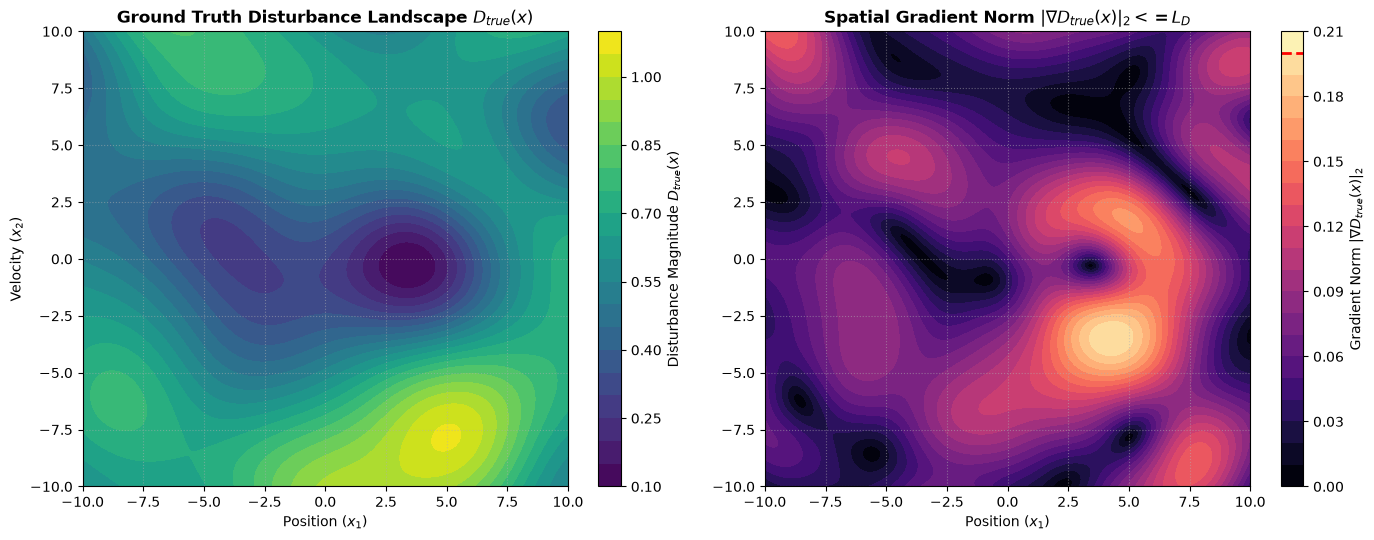

In [9]:
# Verification & Inspection Plot for random Spatio Lipschitz-Continuous Ground Truth Disturbance

# Generate Ground Truth Landscape
d_true_fn_verify = create_random_spatio_lipschitz_landscape(
    grid, L_D=L_D_target, d_base=d_base, seed=seed
)

# Evaluate D_true over grid
d_true_map = jax.vmap(jax.vmap(d_true_fn_verify))(grid.states)

# Verify local gradient magnitudes ||grad D_true(x)||_2
grad_d_fn = jax.grad(d_true_fn_verify)
grad_map = jax.vmap(jax.vmap(grad_d_fn))(grid.states)
grad_norm_map = jnp.linalg.norm(grad_map, axis=-1)

print("==================================================")
print(f"Target Lipschitz Constant (L_D)  : {L_D_target:.4f}")
print(f"Max Measured Spatial Gradient   : {jnp.max(grad_norm_map):.4f}")
print(f"Min Disturbance Value           : {jnp.min(d_true_map):.4f}")
print(f"Max Disturbance Value           : {jnp.max(d_true_map):.4f}")
print("==================================================")

# Plot Ground Truth Landscape and Gradient Norm Map
x1_coords = grid.coordinate_vectors[0]
x2_coords = grid.coordinate_vectors[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: D_true(x)
cf1 = axes[0].contourf(x1_coords, x2_coords, d_true_map.T, levels=20, cmap='viridis')
fig.colorbar(cf1, ax=axes[0], label="Disturbance Magnitude $D_{true}(x)$")
axes[0].set_title("Ground Truth Disturbance Landscape $D_{true}(x)$", fontweight="bold")
axes[0].set_xlabel("Position ($x_1$)")
axes[0].set_ylabel("Velocity ($x_2$)")
axes[0].grid(True, linestyle=":", alpha=0.5)

# Plot 2: ||grad D_true(x)||_2 to verify Lipschitz bound
nabla = "\u2207"
cf2 = axes[1].contourf(x1_coords, x2_coords, grad_norm_map.T, levels=20, cmap='magma')
cbar2 = fig.colorbar(cf2, ax=axes[1], label="Gradient Norm $| " + nabla + " D_{true}(x) |_2$")
cbar2.ax.axhline(L_D_target, color='red', linestyle='--', linewidth=2, label="Max $L_D$ Bound")
axes[1].set_title("Spatial Gradient Norm $| " + nabla + " D_{true}(x) |_2 <= L_D$", fontweight="bold")
axes[1].set_xlabel("Position ($x_1$)")
axes[1].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
# Verification & Inspection Plot for random Spatio-Temporal Lipschitz-Continuous Ground Truth Disturbance

grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    domain=hj.sets.Box(jnp.array([-10.0, -10.0]), jnp.array([10.0, 10.0])),
    shape=(101, 101)
)

t_span = np.linspace(0.0, 5.0, 51)  # 5s animation

# 1. Instantiate Spatio-Temporal Landscape starting flat at t=0
d_spatiotemporal_fn = create_spatiotemporal_lipschitz_landscape(
    grid=grid,
    L_D=L_D_target,
    L_T=L_T_target,
    d_base=0.10,
    start_uniform=False,
    t_max=5.0,
    seed=seed,
)

# 2. Run Verification Check
metrics = verify_spatiotemporal_bounds(
    d_spatiotemporal_fn, grid, t_span, L_D=L_D_target, L_T=L_T_target
)

# 3. Build Animation showing 2D Landscape + L_D and L_T Bound Verification Plots
anim_obj = animate_spatiotemporal_landscape(
    d_spatiotemporal_fn, 
    grid, 
    t_span, 
    L_D=L_D_target,
    L_T=L_T_target,
    u_max=u_max, 
    title="Spatio-Temporal Disturbance Landscape $D(x, t)$"
)

# Render HTML5 Video
HTML(anim_obj.to_html5_video())

SPATIO-TEMPORAL LIPSCHITZ BOUND VERIFICATION
Target Spatial Lipschitz Bound (L_D)  : 0.2000
Max Measured Spatial Gradient        : 0.2004  (Pass: True)
Target Temporal Lipschitz Bound (L_T) : 0.4000
Max Measured Temporal Rate           : 0.3798  (Pass: True)
Disturbance Value Range               : [0.1782, 1.0842]
Evaluating disturbance maps and gradient verification metrics...


In [11]:
# PLOT POINTS AND INDIVIDUAL CONES FOR VISUALIZATION

d_true_fn = create_random_spatio_lipschitz_landscape(
    grid, L_D=L_D_target, d_base=d_base, seed=seed, extension=0
)

sampled_disturbances = jax.vmap(d_true_fn)(sampled_points)

def create_single_cone_fn(x_sample, d_sample, L_D_bound):
    def cone_fn(state):
        dist = jnp.linalg.norm(state - x_sample)
        return d_sample + L_D_bound * dist
    return cone_fn

cone_functions = [
    create_single_cone_fn(sampled_points[i], sampled_disturbances[i], L_D_target)
    for i in range(len(sampled_points))
]

d_true_map = jax.vmap(jax.vmap(d_true_fn))(grid.states)
cone_maps = [jax.vmap(jax.vmap(c_fn))(grid.states) for c_fn in cone_functions]

print("Sampled Points and Corresponding Disturbances")

Sampled Points and Corresponding Disturbances


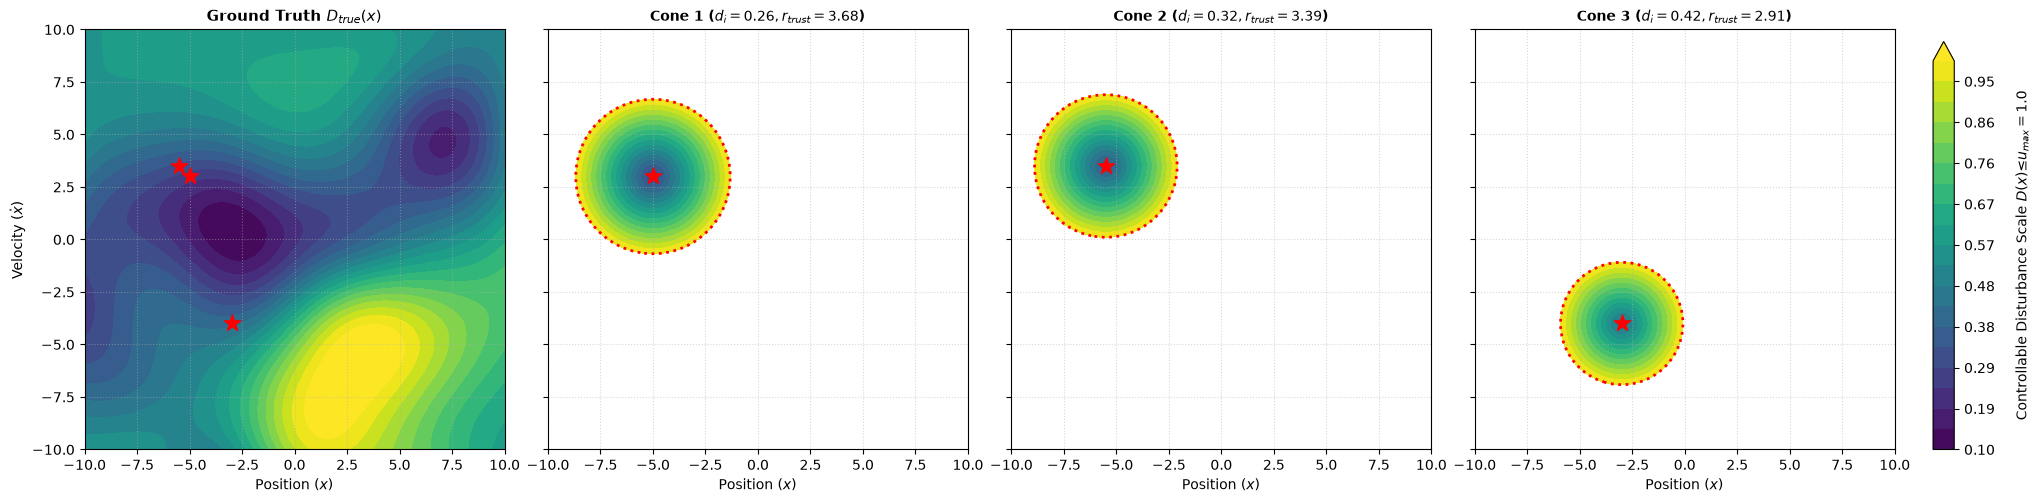

In [12]:
# VISUALIZATION: Ground Truth vs. Individual Cones

# Color scale strictly bounded by control authority (vmax = u_max)
vmin = float(np.floor(d_true_map.min() * 10) / 10.0)  # e.g., 0.10
vmax = u_max                                          # e.g., 1.00

# Color levels strictly within the Controllable Trust Region [0.1, 1.0]
levels = np.linspace(vmin, vmax, 20)

x1_coords = grid.coordinate_vectors[0]
x2_coords = grid.coordinate_vectors[1]

num_plots = 1 + len(cone_maps)  # Total number of subplots: 1 for ground truth + 4 cones
fig_width = 26.5/5 * num_plots

fig, axes = plt.subplots(1, num_plots, figsize=(fig_width, 6.0), sharey=True)

for ax in axes:
    ax.set_aspect('equal')

# Plot 0: Ground Truth D_true(x)
cf0 = axes[0].contourf(x1_coords, x2_coords, d_true_map.T, levels=levels, cmap='viridis', extend='max')
axes[0].scatter(sampled_points[:, 0], sampled_points[:, 1], color='red', marker='*', s=150, zorder=5)
axes[0].set_title("Ground Truth $D_{true}(x)$", fontweight="bold", fontsize=11)
axes[0].set_xlabel("Position ($x$)")
axes[0].set_ylabel("Velocity ($\\dot{x}$)")
axes[0].grid(True, linestyle=":", alpha=0.5)

# Plots 1-4: Individual Cones showing Controllable Trust Circles
for i, cone_map in enumerate(cone_maps):
    ax = axes[i + 1]
    
    # Fill contours ONLY inside the controllable region (D <= u_max)
    cf = ax.contourf(x1_coords, x2_coords, cone_map.T, levels=levels, cmap='viridis')
    
    # Draw red dotted Trust Boundary (D = u_max)
    ax.contour(x1_coords, x2_coords, cone_map.T, levels=[u_max], colors='red', linestyles='dotted', linewidths=2.0)
    
    # Draw sample marker
    ax.scatter(sampled_points[i, 0], sampled_points[i, 1], color='red', marker='*', s=150, zorder=5)
    
    # Calculate analytical trust radius for title
    d_val = float(sampled_disturbances[i])
    r_trust = max(0.0, (u_max - d_val) / L_D_target) if d_val <= u_max else 0.0
    
    ax.set_title(f"Cone {i+1} ($d_{{i}}={d_val:.2f}, r_{{trust}}={r_trust:.2f}$)", fontweight="bold", fontsize=10)
    ax.set_xlabel("Position ($x$)")
    ax.grid(True, linestyle=":", alpha=0.5)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.18, 0.01, 0.68])
cbar = fig.colorbar(cf0, cax=cbar_ax, format='%.2f')
cbar.set_label(f"Controllable Disturbance Scale $D(x) ≤ u_{{max}} = {u_max}$", labelpad=15)

plt.subplots_adjust(left=0.04, right=0.91, bottom=0.18, top=0.88, wspace=0.02)
plt.show()

In [13]:
# PLOT COMBINED LANDSCAPE (POINTWISE MINIMUM OF ALL CONES)

def combined_disturbance_fn(state):
    """
    Computes D_combined(x) = min_i ( d_i + L_D_target * ||x - x_i||_2 )
    takes the minimum overapproximation of disturbance at point i among all sampled cones.
    """
    dists = jnp.linalg.norm(state - sampled_points, axis=-1)  # Shape: (K,)
    cone_values = sampled_disturbances + L_D_target * dists         # Shape: (K,)
    return jnp.min(cone_values) 

# Evaluate maps over grid
d_true_map = jax.vmap(jax.vmap(d_true_fn))(grid.states)
d_combined_map = jax.vmap(jax.vmap(combined_disturbance_fn))(grid.states)

print("Combined Disturbance Landscape Computation Complete.")

Combined Disturbance Landscape Computation Complete.


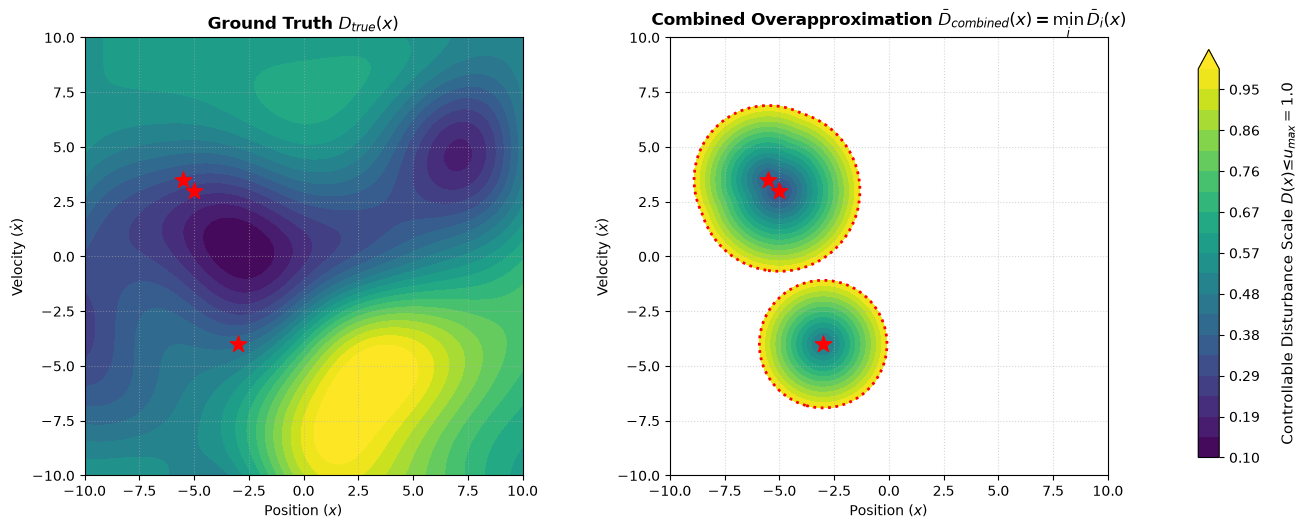

In [14]:
# VISUALIZATION: Ground Truth vs. Combined Landscape

vmin = float(np.floor(d_true_map.min() * 10) / 10.0)
vmax = u_max
levels = np.linspace(vmin, vmax, 20)

x1_coords = grid.coordinate_vectors[0]
x2_coords = grid.coordinate_vectors[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.0), sharey=False)

for ax in axes:
    ax.set_aspect('equal')

# --- Plot 1: Ground Truth D_true(x) ---
cf0 = axes[0].contourf(x1_coords, x2_coords, d_true_map.T, levels=levels, cmap='viridis', extend='max')
axes[0].scatter(sampled_points[:, 0], sampled_points[:, 1], color='red', marker='*', s=150, zorder=5)

axes[0].set_title("Ground Truth $D_{true}(x)$", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Position ($x$)")
axes[0].set_ylabel("Velocity ($\\dot{x}$)")
axes[0].grid(True, linestyle=":", alpha=0.5)

# --- Plot 2: Combined Landscape D_combined(x) ---
cf1 = axes[1].contourf(x1_coords, x2_coords, d_combined_map.T, levels=levels, cmap='viridis')
axes[1].contour(x1_coords, x2_coords, d_combined_map.T, levels=[u_max], colors='red', linestyles='dotted', linewidths=2.0)
axes[1].scatter(sampled_points[:, 0], sampled_points[:, 1], color='red', marker='*', s=150, zorder=5)

axes[1].set_title("Combined Overapproximation $\\bar{D}_{combined}(x) = \\min_i \\bar{D}_i(x)$", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Position ($x$)")
axes[1].set_ylabel("Velocity ($\\dot{x}$)")
axes[1].grid(True, linestyle=":", alpha=0.5)

# --- Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.68])
cbar = fig.colorbar(cf0, cax=cbar_ax, format='%.2f')
cbar.set_label(f"Controllable Disturbance Scale $D(x) ≤ u_{{max}} = {u_max}$", labelpad=15, fontsize=11)

plt.subplots_adjust(left=0.08, right=0.90, bottom=0.15, top=0.88, wspace=0.04)
plt.show()

In [15]:
### Nominal double integrator dynamics

# Initial state and simulation parameters
x_init = jnp.array([-8.0, 5.0])
dt = 0.04
total_steps = 400

# Simple PD feedback controller to steer toward origin [0, 0]
def nominal_controller(state):
    x1, x2 = state[0], state[1]
    u_raw = -0.8 * x1 - 1.2 * x2
    return jnp.clip(u_raw, -u_max, u_max)

# Simulate continuous trajectory
traj_states = [x_init]
curr_state = x_init

for _ in range(total_steps):
    u = nominal_controller(curr_state)
    # Double integrator Euler step: x1_new = x1 + x2*dt, x2_new = x2 + u*dt
    next_x1 = curr_state[0] + curr_state[1] * dt
    next_x2 = curr_state[1] + u * dt
    curr_state = jnp.array([next_x1, next_x2])
    traj_states.append(curr_state)

traj_states = jnp.array(traj_states)  # Shape: (201, 2)

print("Nominal Trajectory Simulation Complete.")

Nominal Trajectory Simulation Complete.


In [16]:
# New Grid Generation Based on Furthest Trajectory Excursion

# --- 1. Find Maximum Trajectory Excursion ---
max_traj_val = float(jnp.max(jnp.abs(traj_states)))

print(f"Maximum Trajectory Excursion: {max_traj_val:.2f}")

# --- 2. Adaptive Whole Number (Integer) Axis Limit L in [10, 20] ---
padding = 1.0  # Buffer margin around trajectory peak
needed_limit = max_traj_val + padding

# Ceiling to get whole number integer increment
L_int = int(np.ceil(needed_limit))

# Clamp integer L between minimum 10 and maximum 20
L = float(max(10, min(20, L_int)))

grid_lower = jnp.array([-L, -L])
grid_upper = jnp.array([L, L])

# --- 3. Maintain Consistent Grid Resolution (10 points per unit) ---
pts_per_unit = 10
grid_shape = (int(2 * L * pts_per_unit) + 1, int(2 * L * pts_per_unit) + 1)

# --- 4. Instantiate Grid ---
traj_grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    domain=hj.sets.Box(grid_lower, grid_upper),
    shape=grid_shape
)

print(f"Adaptive Grid Bounds: [{grid_lower[0]:.0f}, {grid_upper[0]:.0f}] x [{grid_lower[1]:.0f}, {grid_upper[1]:.0f}] (L = {int(L)})")

Maximum Trajectory Excursion: 8.00
Adaptive Grid Bounds: [-10, 10] x [-10, 10] (L = 10)


In [17]:
# Sample points uniformally in time along the nominal trajectory

num_samples = 10
sample_indices = np.linspace(0, len(traj_states) - 1, num=num_samples, dtype=int)
sampled_points = traj_states[sample_indices]

# Measure ground truth disturbance at each sampled point
sampled_disturbances = jax.vmap(d_true_fn)(sampled_points)

# Evaluate grid maps
d_true_map = jax.vmap(jax.vmap(d_true_fn))(traj_grid.states)
d_combined_map = jax.vmap(jax.vmap(combined_disturbance_fn))(traj_grid.states)

print("Sampled Points and Disturbances Recorded.")

Sampled Points and Disturbances Recorded.


In [18]:
# Sample points at boundary of trust region (D_combined(x) >= u_max - epsilon) along the nominal trajectory

def sample_adaptive_trajectory_cones(
    traj_states,
    d_true_fn,
    u_max=1.0,
    L_D=0.25,
    epsilon=0.02,
    min_step_dist=0.3
):
    """
    Adaptively samples disturbance upper-bound cones along a nominal trajectory 
    based on trust-boundary crossing (D_combined(x) >= u_max - epsilon).

    Parameters:
    -----------
    traj_states : jnp.ndarray, shape (T, 2)
        Array of trajectory states [x_1, x_2] across time steps.
    d_true_fn : callable
        Function returning true disturbance bound D_true(state).
    u_max : float
        Maximum control authority.
    L_D : float
        Lipschitz constant of the disturbance landscape.
    epsilon : float
        Safety buffer margin below u_max to trigger re-sampling.
    min_step_dist : float
        Minimum Euclidean distance between successive sample points to handle 
        near-zero trust radius safeguards.

    Returns:
    --------
    results : dict
        Dictionary containing sampled_points, sampled_disturbances, 
        sampled_indices, status, message, and termination flags.
    """
    
    sampled_points = []
    sampled_disturbances = []
    sampled_indices = []

    def evaluate_combined_d(state, pts, dists):
        """Evaluates pointwise minimum over all existing cones at state x."""
        if len(pts) == 0:
            return float('inf')
        pts_arr = jnp.array(pts)
        dists_arr = jnp.array(dists)
        distances = jnp.linalg.norm(state - pts_arr, axis=-1)
        cone_vals = dists_arr + L_D * distances
        return jnp.min(cone_vals)


    # Initial state
    x_init = traj_states[0]
    d_init = float(d_true_fn(x_init))

    # Safeguard: Initial state is uncontrollable
    if d_init >= u_max:
        return {
            "status": "FAILED_UNCONTROLLABLE_REGION_ENTERED",
            "message": f"Initial trajectory state x(0)={np.array(x_init)} has D_true={d_init:.3f} >= u_max ({u_max}). Uncontrollable!",
            "sampled_points": jnp.array([x_init]),
            "sampled_disturbances": jnp.array([d_init]),
            "sampled_indices": [0],
            "num_samples": 0,
            "terminated_early": True,
            "fully_covered": False
        }

    sampled_points.append(x_init)
    sampled_disturbances.append(d_init)
    sampled_indices.append(0)


    # Sequential Adaptive Sampling Loop
    terminated_early = False
    status_code = "SUCCESS_TRAJECTORY_FULLY_COVERED"
    status_message = "Entire trajectory was successfully traversed within the guaranteed trust boundary."

    trigger_threshold = u_max - epsilon

    for i in range(1, len(traj_states)):
        x_curr = traj_states[i]

        # 1. Evaluate current overapproximation from existing cones
        # SAFEGUARD (Redundant Cones): If d_combined < trigger_threshold, 
        # existing cones cover this state; no new sample needed.
        d_combined_curr = float(evaluate_combined_d(x_curr, sampled_points, sampled_disturbances))

        # 2. Check if state reaches/exceeds the Trust Boundary threshold
        if d_combined_curr >= trigger_threshold:
            
            # SAFEGUARD (Near-Zero Trust Radius):
            # Check Euclidean distance from the most recently added sample point
            dist_from_last = float(jnp.linalg.norm(x_curr - jnp.array(sampled_points[-1])))

            if dist_from_last >= min_step_dist:
                # Query ground truth at the boundary crossing point
                d_curr = float(d_true_fn(x_curr))

                # SAFEGUARD / TERMINATION (Impossible Control Recovery):
                # If D_true(x) >= u_max, disturbance overwhelms control authority.
                if d_curr >= u_max:
                    sampled_points.append(x_curr)
                    sampled_disturbances.append(d_curr)
                    sampled_indices.append(i)
                    
                    status_code = "FAILED_UNCONTROLLABLE_REGION_ENTERED"
                    status_message = (
                        f"Trajectory reached uncontrollable state at step {i} (x={np.array(x_curr)}). "
                        f"D_true={d_curr:.3f} >= u_max ({u_max}). Trajectory terminated early!"
                    )
                    terminated_early = True
                    break

                # Add valid new sample point and update combined overapproximation
                sampled_points.append(x_curr)
                sampled_disturbances.append(d_curr)
                sampled_indices.append(i)

    # Convert to JAX arrays for downstream solver / plotting compatibility
    sampled_points_arr = jnp.array(sampled_points)
    sampled_disturbances_arr = jnp.array(sampled_disturbances)

    return {
        "status": status_code,
        "message": status_message,
        "sampled_points": sampled_points_arr,
        "sampled_disturbances": sampled_disturbances_arr,
        "sampled_indices": sampled_indices,
        "num_samples": len(sampled_points),
        "terminated_early": terminated_early,
        "fully_covered": not terminated_early
    }

In [19]:
# Compute Adaptive Sampling along the nominal trajectory

# --- Execute Adaptive Sampling ---
sampling_result = sample_adaptive_trajectory_cones(
    traj_states=traj_states,
    d_true_fn=d_true_fn,
    u_max=u_max,
    L_D=L_D_target,
    epsilon=epsilon_buffer,
    min_step_dist=min_step_dist
)

# Extract variables with original variable names for plot compatibility
sampled_points = sampling_result["sampled_points"]
sampled_disturbances = sampling_result["sampled_disturbances"]

# Print execution status and trust boundary summary
print("==================================================")
print(f"SAMPLING STATUS      : {sampling_result['status']}")
print(f"TERMINATED EARLY     : {sampling_result['terminated_early']}")
print(f"FULLY TRUST COVERED  : {sampling_result['fully_covered']}")
print(f"TOTAL SAMPLES TAKEN  : {sampling_result['num_samples']}")
print(f"DETAILS              : {sampling_result['message']}")
print("==================================================")

# Evaluate over grid for visualization cells
d_true_map = jax.vmap(jax.vmap(d_true_fn))(traj_grid.states)
d_combined_map = jax.vmap(jax.vmap(combined_disturbance_fn))(traj_grid.states)

print("Combined Landscape Map for adaptive sampling, ready for visualization.")

SAMPLING STATUS      : SUCCESS_TRAJECTORY_FULLY_COVERED
TERMINATED EARLY     : False
FULLY TRUST COVERED  : True
TOTAL SAMPLES TAKEN  : 9
DETAILS              : Entire trajectory was successfully traversed within the guaranteed trust boundary.
Combined Landscape Map for adaptive sampling, ready for visualization.


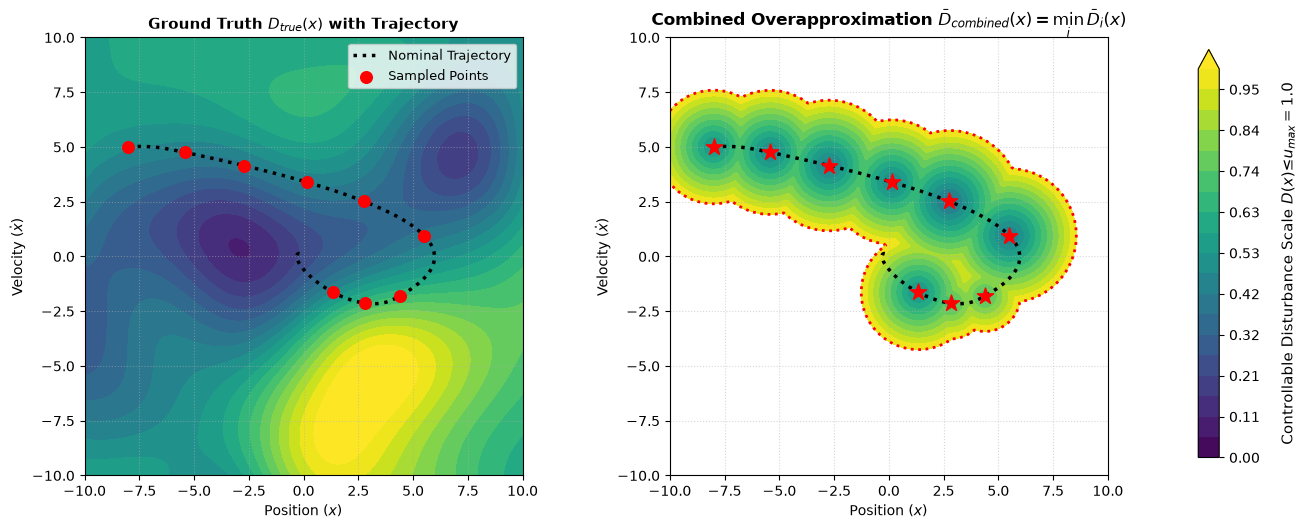

In [20]:
# VISUALIZATION: Ground Truth vs. Combined Landscape with Nominal Trajectory and Sampled Points
x1_coords = traj_grid.coordinate_vectors[0]
x2_coords = traj_grid.coordinate_vectors[1]

vmin = float(np.floor(d_true_map.min() * 10) / 10.0)
vmax = u_max
levels = np.linspace(vmin, vmax, 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.0), sharey=False)

for ax in axes:
    ax.set_aspect('equal')

# --- Plot 1: Ground Truth D_true(x) with Nominal Trajectory ---
cf0 = axes[0].contourf(x1_coords, x2_coords, d_true_map.T, levels=levels, cmap='viridis', extend='max')

# Dotted black nominal trajectory
axes[0].plot(traj_states[:, 0], traj_states[:, 1], color='black', linestyle=':', linewidth=2.5, label='Nominal Trajectory')
axes[0].scatter(sampled_points[:, 0], sampled_points[:, 1], color='red', marker='o', s=70, zorder=5, label='Sampled Points')

axes[0].set_xlim([-L, L])
axes[0].set_ylim([-L, L])
axes[0].set_title("Ground Truth $D_{true}(x)$ with Trajectory", fontweight="bold", fontsize=11)
axes[0].set_xlabel("Position ($x$)")
axes[0].set_ylabel("Velocity ($\\dot{x}$)")
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, linestyle=":", alpha=0.5)


# --- Plot 2: Combined Landscape D_combined(x) ---
cf1 = axes[1].contourf(x1_coords, x2_coords, d_combined_map.T, levels=levels, cmap='viridis')
axes[1].contour(x1_coords, x2_coords, d_combined_map.T, levels=[u_max], colors='red', linestyles='dotted', linewidths=2.0)
axes[1].plot(traj_states[:, 0], traj_states[:, 1], color='black', linestyle=':', linewidth=2.5, label='Nominal Trajectory')
axes[1].scatter(sampled_points[:, 0], sampled_points[:, 1], color='red', marker='*', s=150, zorder=5)

axes[1].set_xlim([-L, L])
axes[1].set_ylim([-L, L])
axes[1].set_title("Combined Overapproximation $\\bar{D}_{combined}(x) = \\min_i \\bar{D}_i(x)$", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Position ($x$)")
axes[1].set_ylabel("Velocity ($\\dot{x}$)")
axes[1].grid(True, linestyle=":", alpha=0.5)



# --- Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.68])
cbar = fig.colorbar(cf0, cax=cbar_ax, format='%.2f')
cbar.set_label(f"Controllable Disturbance Scale $D(x) ≤ u_{{max}} = {u_max}$", labelpad=15, fontsize=11)

plt.subplots_adjust(left=0.08, right=0.90, bottom=0.15, top=0.88, wspace=0.04)
plt.show()

In [21]:
# Solver HJ Reachability Execution Loop across all Landscapes

u_max = 1.0
time_start = 0.0
time_target = -2.0  
times = jnp.linspace(time_start, time_target, 101)

# BRS
# solver_settings = hj.SolverSettings.with_accuracy("high")

# BRT
solver_settings = hj.SolverSettings.with_accuracy(
    "high",
    hamiltonian_postprocessor=hj.solver.backwards_reachable_tube
)

landscapes = [
    {"name": "1. Uniform Field", "fn": landscape_1_uniform},
    {"name": "2. Random Lipschitz Landscape", "fn": d_true_fn},
    {"name": "3. Radial Growth ($L_D=0.25$)", "fn": landscape_4_radial_growth},
]

results = []

for idx, landscape in enumerate(landscapes):
    print(f"Solving HJ PDE equations for Landscape: {landscape['name']}...")
    
    # Initialize game dynamics (control MINIMIZES, disturbance MAXIMIZES)
    game_dyn = DoubleIntDynamics(u_max=u_max, landscape_fn=landscape["fn"])
    
    # Initialize net capability underapproximation dynamics
    net_dyn = NetCapabilityDynamics(u_max=u_max, landscape_fn=landscape["fn"])
    
    # Propagate value functions backward through time using hj.solve
    game_values = hj.solve(solver_settings, game_dyn, grid, times, initial_values)
    net_values = hj.solve(solver_settings, net_dyn, grid, times, initial_values)
    
    # Vectorize landscape calculations across the state grid for plotting
    landscape_map = jax.vmap(jax.vmap(landscape["fn"]))(grid.states)
    
    # Store final values (at time t = -2.0)
    results.append({
        "name": landscape["name"],
        "game_v": game_values[-1],
        "net_v": net_values[-1],
        "map": landscape_map
    })

print("All reachability computations completed successfully.")

Solving HJ PDE equations for Landscape: 1. Uniform Field...


ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 101: axis 1 of argument state of type float32[101,101,2];
  * one axis had size 201: axis 1 of argument value of type float32[201,201]

In [ ]:
# # Generate Comparative Plots

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

x1_coords = grid.coordinate_vectors[0]
x2_coords = grid.coordinate_vectors[1]

# Define plot display bounds based on the enlarged grid
X1_LIMITS = (grid_lower[0], grid_upper[0])  # Position range
X2_LIMITS = (grid_lower[1], grid_upper[1])  # Velocity range

for i, res in enumerate(results):
    ax = axes[i]
    
    # 1. Plot Disturbance Landscape Background
    contour_bg = ax.contourf(
        x1_coords, x2_coords, res["map"].T, 
        levels=15, cmap='viridis', alpha=0.6
    )
    
    # 2. Target Boundary (Dotted Line)
    ax.contour(
        x1_coords, x2_coords, initial_values.T, levels=[0.0], 
        colors="black", linestyles="dotted", linewidths=1.5
    )
    
    # 3. True Game Reachable Set Boundary (Solid Line)
    ax.contour(
        x1_coords, x2_coords, res["game_v"].T, levels=[0.0], 
        colors="black", linestyles="solid", linewidths=2.5
    )
    
    # 4. Trust Region Boundary where D(x) = u_max (Red Dotted Line)
    ax.contour(
        x1_coords, x2_coords, res["map"].T, levels=[u_max],
        colors="red", linestyles="dotted", linewidths=2.5
    )
    
    ax.set_xlim(X1_LIMITS)
    ax.set_ylim(X2_LIMITS)
    
    # Grid ticks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5.0))  # Ticks every 5 units for Position
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2.0))  # Ticks every 2 units for Velocity
    
    ax.set_title(res["name"], fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Position ($x_1$)", fontsize=12)
    if i == 0:
        ax.set_ylabel("Velocity ($x_2$)", fontsize=12)
        
    ax.grid(True, linestyle=":", alpha=0.5, color="gray")

# Custom Legend below plots
legend_lines = [
    plt.Line2D([0], [0], color="black", linestyle=":", linewidth=1.5),
    plt.Line2D([0], [0], color="black", linestyle="solid", linewidth=2.5),
    plt.Line2D([0], [0], color="red", linestyle=":", linewidth=2.5)
]

fig.legend(
    legend_lines, 
    [
        "Initial Target Set", 
        "True Double Integrator Reachable Set", 
        f"Trust Boundary ($D(x) = u_{{max}} = {u_max}$)"
    ], 
    loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=11, frameon=True
)

# Colorbar placement
cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.68])
cbar = fig.colorbar(contour_bg, cax=cbar_ax)
cbar.set_label("Adversarial Disturbance Bound Magnitude $D(x)$", fontsize=11, labelpad=10)

plt.subplots_adjust(left=0.06, right=0.90, bottom=0.16, top=0.88, wspace=0.12)
plt.show()